# 11_gene_expression_R

In [1]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyverse)
  library(Matrix)
  library(Hmisc)
  library(reshape2)
  library(viridis)
  library(RColorBrewer)
  library(ggalluvial)
  library(gplots)
  library(grid)
  library(ggforce)
library(scales)

library(gridExtra)    
library(rlang)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Warning message:
“package ‘readr’ was built under R version 4.5.2”
Warning message:
“package ‘purrr’ was built under R version 4.5.2”
Warning message:
“package ‘stringr’ was built under R version 4.5.2”
Warning message:
“package ‘reshape2’ was built under R version 4.5.2”


In [2]:
options(tibble.width = Inf)
options(repr.matrix.max.cols = Inf)

## plot parameters

In [3]:
# define const for visualization
FONT.SIZE <- 7
LABEL.FONT.SIZE <- 7
w <- 2 
h <- 2.5
LINE.W <- 0.3 

settheme <- theme_minimal() + 
  theme(
    text = element_text(family = "sans"), 
    panel.background = element_blank(),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(),
    plot.background = element_blank(),
    
    axis.ticks = element_line(colour = "black", linewidth = LINE.W),
    axis.ticks.length = unit(0.1, "cm"), 
    axis.line = element_line(linewidth = LINE.W, colour = "black"),
    axis.title = element_text(size = FONT.SIZE),
    axis.text = element_text(colour = "black", size = FONT.SIZE),
    strip.text = element_text(size = FONT.SIZE), 
    strip.text.y.left = element_text(angle = 0, hjust = 1, size = FONT.SIZE),
    legend.position = "right",
    legend.title = element_text(size = FONT.SIZE), 
    legend.text = element_text(size = FONT.SIZE),
    legend.key.size = unit(0.3, "cm"),
    axis.text.x = element_text(colour = "black", angle = 0, size = LABEL.FONT.SIZE),
    title = element_text(size = FONT.SIZE) 
)


In [4]:
custom_palette <- c(
  "#555e7b", "#b7d968", "#b576ad", "#e04644", "#fde47f", "#7ccce5", 
  "#C6E5D9", "#F0A830", "#e04644", "#C0D860", "#F2F26F", "#A8E6CE", 
  "#CCC68D", "#EB6841", "#E1F5C4", "#D9CEB2", "#C5CEAE", "#E84A5F", 
  "#A0C55F", "#DCE9BE", "#FFAAA6", "#F07818", "#E08E79", "#A0C55F", 
  "#948C75", "#C0D860", "#005F6B", "#45484B", "#0B2E59", "#FFF7BD", 
  "#CFBE27", "#F1D4AF", "#C02942", "#5E412F", "#355C7D", "#F27435", 
  "#AAB3AB", "#4ECDC4", "#8C2318", "#FF9E9D", "#E6AC27", "#C7F464", 
  "#4ECDC4", "#ED303C", "#F4FAD2", "#F07818", "#031634", "#838689", 
  "#73626E", "#F9D423", "#C06C84", "#F04155", "#F5634A", "#DFBA69", 
  "#A0C55F"
)

color_ploidy = c("diploid"= "white","normal"= "white", "monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0")
color_ploidy_2 = c("diploid"= adjustcolor("grey77", alpha = 0.5) ,"normal"= "white", "monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0")
color_ploidy_chr = c("normal"= "white","monosomy"="#109E9D","trisomy"="#F26B3B")

color_condition = c("Control" = "#7BBA56", 
               "Reversine" = "#87549B", 
               "Mix" = "#E8973E")

color_celltype = c("EPI"    = "#EA9542", 
                   "TE"       = "#3E7CB5", 
                   "unspecified"       = "#7CBA59")

color_sample = c(
  # Control group colors
  "T1_control" = "#B5C649",
  "T2_control" = "#66BC52",
  "T3_control" = "#009791",
  # Reversine group colors
  "T1_rev" = "#B686BD",
  "T2_rev" = "#A263B2",
  "T3_naive_rev" = "#754383",
  "T3_rev" = "#4A314F",
  # Mix group colors
  "T2_mix" = "#FDCF5F",
  "T3_mix_good" = "#F29923",
  "T3_mix_bad" = "#945200"
)



levels_vec <- as.character(1:22)
col_monosomy <- viridis_pal(option = "mako")(22)
names(col_monosomy) <- rev(levels_vec)

levels_vec <- as.character(1:22)
col_trisomy <- viridis_pal(option = "rocket")(22)
names(col_trisomy) <- rev(levels_vec)

#c("normal"= "#E0E0E0","monosomy"="#109E9D","trisomy"="#F26B3B")

## Directories and Files

In [5]:
outdir = "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/11_geneexpression"

In [6]:
scploid_df = read_csv( "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/cell_karyotype_scploid.csv")

New names:
• `` -> `...1`
Rows: 38655 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): cell, karyotype, ploidy
dbl (5): ...1, num_gain_chr, num_loss_chr, num_chr, num_abnormal_chr

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
# 1. Load the pieces
# counts <- readMM(sprintf("%s/matrix.mtx",outdir))
# genes  <- read_csv("scanpy_export_for_R/genes.csv")$cell_symbol # Check col name in CSV
# meta   <- read_csv("scanpy_export_for_R/metadata.csv") %>% rename(barcode = 1)
# umap   <- read_csv("scanpy_export_for_R/umap_coords.csv") %>% rename(barcode = 1)
counts <- readMM(sprintf("%s/matrix_hvg.mtx",outdir))
genes  <- read_csv(sprintf("%s/genes_hvg.csv",outdir))$`0`
meta   <- read_csv(sprintf("%s/metadata.csv",outdir))%>% rename(barcode = 1)
umap   <- read_csv(sprintf("%s/umap_coords.csv",outdir))%>% rename(barcode = 1)
mlm_PROGENy_df  <- read_csv(sprintf("%s/progeny_mlm_scores.csv",outdir))
mlm_hallmark_df  <- read_csv(sprintf("%s/hallmark_mlm_scores.csv",outdir))

Rows: 33540 Columns: 1
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): 0

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 38655 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): dataset, cell.ID_, n_genes_group, phase, persample_celltype, sampl...
dbl (23): ...1, scrublet_score, scrublet_cluster_score, scrublet_zscore, scr...
lgl  (1): scrublet_prediction

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 38655 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): ...1, UMAP1, UMAP2

ℹ Use `spec()` to retrieve the full column specifi

## Reformat

In [8]:
rownames(counts) <- genes
colnames(counts) <- meta$barcode # or barcode col

In [9]:
meta <- meta %>% mutate(barcode = as.character(barcode))
umap <- umap %>% mutate(barcode = as.character(barcode))
plot_base <- meta %>% left_join(umap, by = "barcode")

In [10]:
# Combine
gene_exp <- as.matrix(t(counts))
gene_exp_df <- as_tibble(gene_exp, rownames = "barcode")


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 9.7 GiB”


In [11]:
## Run this if not subsetting
# Join with our UMAP and Metadata
meta_genes_df= plot_base %>% left_join(gene_exp_df, by = "barcode")

# Combine with scpoid
meta_genes_df <- meta_genes_df %>% 
  mutate(cell.ID_ = as.character(cell.ID_))

scploid_df <- scploid_df %>% 
  mutate(cell = as.character(cell))

# 2. Join the dataframes
# We use 'c("target_col_in_left" = "target_col_in_right")'
combined_df <- meta_genes_df %>%
  left_join(scploid_df, by = c("cell.ID_" = "cell"))

In [12]:
apoptosis = c("AEN", "RPS27L", "GPX1", "EDA2R", "CDKN1A", "RRM2B", "BCL2L13")

stress_response = c("CALM3", "SESN1", "POLH", "DDB2", "PPM1D", "KCNK1", "MDM2", "PLK2", "CEP63",
                    "NUCKS1", "GTF2H5","ATP6V0A2", "PLEKHA1")

adhesion = c("CDH1", "TJP1",  #ZO1
             "ACTB", "ACTG1",  "ITGB1", "ITGA6", "ITGAV", "ITGB5",
            "NECTIN2", "F11R" ,#JAM1
             "CDH3", "EPCAM", "DSG2","GJA1",
            "OCLN", "PVR", "NECTIN1", "BCAM", "ICAM1", "ITGA9", "CLDN1", "ITGA2", "CXADR")

adhesion_sub = c("CDH1",  #E-CAD
               "ACTB", "ACTG1",  #F-actin components
                 "OCLN","CLDN1","TJP1","F11R",  #ZO1, tight junction related
                 "GJA1", #gap junction
                 "EPCAM") #Epithelial Cell Adhesion Molecule


mlm_PROGENy_var = setdiff(colnames(mlm_PROGENy_df), "cell")
mlm_hallmark_var = c('APICAL_JUNCTION', 'APICAL_SURFACE', 'APOPTOSIS',
       'COMPLEMENT', 'DNA_REPAIR', 'E2F_TARGETS',
       'EPITHELIAL_MESENCHYMAL_TRANSITION', 'ESTROGEN_RESPONSE_EARLY',
       'ESTROGEN_RESPONSE_LATE', 'FATTY_ACID_METABOLISM', 'G2M_CHECKPOINT',
       'GLYCOLYSIS', 'HEDGEHOG_SIGNALING', 'HYPOXIA',
       'IL2_STAT5_SIGNALING', 'IL6_JAK_STAT3_SIGNALING',
       'INFLAMMATORY_RESPONSE', 'INTERFERON_ALPHA_RESPONSE',
       'INTERFERON_GAMMA_RESPONSE', 'KRAS_SIGNALING_DN', 'KRAS_SIGNALING_UP',
       'MITOTIC_SPINDLE', 'MTORC1_SIGNALING', 'MYC_TARGETS_V1',
       'MYC_TARGETS_V2', 'NOTCH_SIGNALING',
       'OXIDATIVE_PHOSPHORYLATION', 'P53_PATHWAY', 
       'PEROXISOME', 'PI3K_AKT_MTOR_SIGNALING', 'PROTEIN_SECRETION',
       'REACTIVE_OXYGEN_SPECIES_PATHWAY', 
       'TGF_BETA_SIGNALING', 'TNFA_SIGNALING_VIA_NFKB',
       'UNFOLDED_PROTEIN_RESPONSE', 'UV_RESPONSE_DN',
       'WNT_BETA_CATENIN_SIGNALING')

EMT_genes = c("CDH2","SNAI1", "SNAI2", "ZEB1", "ZEB2","TWIST", "VIM")

TE_genes = c( "GATA2", "GATA3", "CDX2", "TFAP2C", "KRT7", "KRT18", "OVOL1")

EPI_genes= c("POU5F1", "GDF3", "ARGFX", "NANOG", "SOX2", "KLF17", "TDGF1")



In [13]:
plot_genes <- unique(c(apoptosis, stress_response, adhesion, TE_genes,EPI_genes, EMT_genes))

In [14]:

## Or subset genes to reduce size
get_gene_plot_data <- function(target_genes) {
    
  # rownames of counts are your valid gene IDs
  genes_in_counts <- rownames(counts)

  # keep only genes that exist
  keep <- intersect(target_genes, genes_in_counts)
  missing <- setdiff(target_genes, genes_in_counts)
  message(paste(head(missing, 20), collapse = ", "))

  # Extract expression for listed genes and convert to dense for the plot
  gene_exp <- as.matrix(t(counts[keep, , drop = FALSE]))
  gene_exp_df <- as_tibble(gene_exp, rownames = "barcode")
  # Join with our UMAP and Metadata
  plot_base %>% left_join(gene_exp_df, by = "barcode")
}

# 1) Start from plot_base + only the genes you need
meta_genes_df <- get_gene_plot_data(plot_genes)

# 2) Make sure the join key exists and is consistent
# If scploid_df uses "cell", create a matching "cell" column in meta_genes_df from barcode
meta_genes_df <- meta_genes_df %>%
  mutate(cell = as.character(barcode))

scploid_df <- scploid_df %>%
  mutate(cell = as.character(cell))

# 3) Join with scploid
combined_df_1 <- meta_genes_df %>%
  left_join(scploid_df, by = c("cell.ID_" =  "cell"))

# 4) Join with mlm_progeny
combined_df_2 <- combined_df_1 %>%
  left_join(mlm_PROGENy_df, by = c("cell.ID_" =  "cell"))

# 4) Join with mlm_hallmark
combined_df <- combined_df_2 %>%
  left_join(mlm_hallmark_df, by = c("cell.ID_" =  "cell"))

TWIST



In [15]:
 # Gene order (top-to-bottom = target_genes order reversed)
  ploidy_order = c("diploid", "trisomy", "monosomy", "complex")
  combined_df$ploidy <- factor(combined_df$ploidy, levels = ploidy_order)

In [16]:
head(combined_df )

barcode,dataset,cell.ID_,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,UMAP1,UMAP2,AEN,RPS27L,GPX1,EDA2R,CDKN1A,RRM2B,BCL2L13,CALM3,SESN1,POLH,DDB2,PPM1D,KCNK1,MDM2,PLK2,CEP63,NUCKS1,GTF2H5,ATP6V0A2,PLEKHA1,CDH1,TJP1,ACTB,ACTG1,ITGB1,ITGA6,ITGAV,ITGB5,NECTIN2,F11R,CDH3,EPCAM,DSG2,GJA1,OCLN,PVR,NECTIN1,BCAM,ICAM1,ITGA9,CLDN1,ITGA2,CXADR,GATA2,GATA3,CDX2,TFAP2C,KRT7,KRT18,OVOL1,POU5F1,GDF3,ARGFX,NANOG,SOX2,KLF17,TDGF1,CDH2,SNAI1,SNAI2,ZEB1,ZEB2,VIM,cell,...1,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,COMPLEMENT,DNA_REPAIR,E2F_TARGETS,EPITHELIAL_MESENCHYMAL_TRANSITION,ESTROGEN_RESPONSE_EARLY,ESTROGEN_RESPONSE_LATE,FATTY_ACID_METABOLISM,G2M_CHECKPOINT,GLYCOLYSIS,HEDGEHOG_SIGNALING,HEME_METABOLISM,HYPOXIA,IL2_STAT5_SIGNALING,IL6_JAK_STAT3_SIGNALING,INFLAMMATORY_RESPONSE,INTERFERON_ALPHA_RESPONSE,INTERFERON_GAMMA_RESPONSE,KRAS_SIGNALING_DN,KRAS_SIGNALING_UP,MITOTIC_SPINDLE,MTORC1_SIGNALING,MYC_TARGETS_V1,MYC_TARGETS_V2,MYOGENESIS,NOTCH_SIGNALING,OXIDATIVE_PHOSPHORYLATION,P53_PATHWAY,PANCREAS_BETA_CELLS,PEROXISOME,PI3K_AKT_MTOR_SIGNALING,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Embryo-Imp15265938,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,0.07129456,FALSE,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.291071261,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified,6.524751,3.467301,0.0000000,1.734258,1.503753,0.0000000,1.0113358,0.0000000,0.0000000,1.5037534,0.7729656,0.7729656,1.0113358,0.4593789,0.0000000,0.0000000,0,0,1.921457,1.2036812,0.4593789,0.4593789,0.0000000,0.4593789,3.325833,3.090645,0.0000000,0.4593789,0,0.0000000,0.4593789,0.7729656,0.0000000,0.0000000,0.7729656,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.0000000,0,0.4593789,0.0000000,0,0.0000000,0,0.000000,0.0000000,0.0000000,0.0000000,0.4593789,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.7729656,0.0000000,2.583612,0,14348,diploid,diploid,0,0,44,0,2.131029,-0.4075289,0.05464372,0.57211532,-1.1875900,1.252161,-1.95

In [17]:
length(plot_genes )

missing <- setdiff(plot_genes , rownames(counts))
length(missing)
head(missing)

[1] 64

[1] 1

[1] "TWIST"

## A_Dot plot

### function

In [18]:
make_gene_dotplot <- function(combined_df,
                                             sample = "sample",
                                             target_genes,
                                             w = 4, h = 3,
                                             title = "Gene Expression vs others mean",
                                             expr_thresh = 0,
                                             endcolor = "#3F8F91",
                                             alpha = 0.05,
                                             highlight_direction =  "up",
                                             delta_min = 0.1,              # effect-size gate (highly recommended)
                                             highlight_color = "black",
                                             highlight_stroke = 0.3,
                                             p_adjust_method = "BH") {

  highlight_direction <- match.arg(highlight_direction)

  df_sub <- combined_df %>%
    select(all_of(sample), any_of(target_genes))

  present_genes <- intersect(target_genes, colnames(df_sub))
  missing_genes <- setdiff(target_genes, present_genes)
  if (length(present_genes) == 0) stop("None of target_genes are present in combined_df.")
  if (length(missing_genes) > 0) message("Dropping missing genes: ", paste(missing_genes, collapse = ", "))

  # Cell-level long table
  long <- df_sub %>%
    pivot_longer(cols = any_of(present_genes),
                 names_to = "gene", values_to = "expression") %>%
    mutate(group = .data[[sample]])

  # Dot summary (for plotting)
  dot_data <- long %>%
    group_by(gene, group) %>%
    summarise(
      avg_exp = mean(expression, na.rm = TRUE),
      pct_exp = sum(expression > expr_thresh, na.rm = TRUE) / n() * 100,
      n_cells = n(),
      .groups = "drop"
    )

  # --- leave-one-group-out mean ("others mean") per gene x group ---
  # For each gene:
  #   total_sum, total_n across all cells
  #   per-group sum_g, n_g
  #   others_mean = (total_sum - sum_g) / (total_n - n_g)
  totals <- long %>%
    group_by(gene) %>%
    summarise(
      total_sum = sum(expression, na.rm = TRUE),
      total_n   = sum(!is.na(expression)),
      .groups = "drop"
    )

  grp_sums <- long %>%
    group_by(gene, group) %>%
    summarise(
      sum_g = sum(expression, na.rm = TRUE),
      n_g   = sum(!is.na(expression)),
      .groups = "drop"
    )

  others_tbl <- grp_sums %>%
    left_join(totals, by = "gene") %>%
    mutate(
      n_others = total_n - n_g,
      others_mean = ifelse(n_others > 0, (total_sum - sum_g) / n_others, NA_real_)
    ) %>%
    select(gene, group, others_mean, n_others)

  # One-sample t-test per (gene, group) vs others_mean
  p_tbl <- long %>%
    left_join(others_tbl, by = c("gene", "group")) %>%
    group_by(gene, group) %>%
    summarise(
      p = {
        x <- expression
        mu <- others_mean[1]
        x <- x[is.finite(x)]
        if (length(x) < 3 || !is.finite(mu)) NA_real_ else suppressWarnings(t.test(x, mu = mu)$p.value)
      },
      .groups = "drop"
    )

  dot_data <- dot_data %>%
    left_join(others_tbl, by = c("gene", "group")) %>%
    left_join(p_tbl,     by = c("gene", "group")) %>%
    mutate(
      delta = avg_exp - others_mean,
      padj = p.adjust(p, method = p_adjust_method),
      highlight = case_when(
        is.na(padj) ~ FALSE,
        highlight_direction == "both" ~ (padj < alpha) & (abs(delta) > delta_min),
        highlight_direction == "up"   ~ (padj < alpha) & (delta >  delta_min),
        highlight_direction == "down" ~ (padj < alpha) & (delta < -delta_min)
      )
    )

  # Gene order
  dot_data$gene <- factor(dot_data$gene, levels = rev(target_genes))

  options(repr.plot.width = w, repr.plot.height = h)

  p_dot <- ggplot(dot_data, aes(x = group, y = gene)) +
    geom_point(aes(size = pct_exp, color = avg_exp)) +
    geom_point(
      data = filter(dot_data, highlight),
      aes(size = pct_exp),
      shape = 21, fill = NA, color = highlight_color, stroke = highlight_stroke,
      inherit.aes = TRUE
    ) +
    scale_color_gradientn(colors = c("white", endcolor)) +
    scale_size_continuous(range = c(0, 6), name = "% Expressed") +
    labs(
      x = "",
      y = "",
      color = "Avg. Expression",
      title = paste0(title, " (ring: adj p<", alpha, " vs mean of others)")
    ) +
    settheme +
    theme(
      axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
      panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.5),
      legend.position = "right"
    )

    ggsave( filename = sprintf("%s/A_%s_%s_dotplot.pdf", outdir, title, sample), plot =  p_dot, width = w, height = h)
    options(repr.plot.width=w, repr.plot.height=h)
    p_dot
}


### plots - by sample

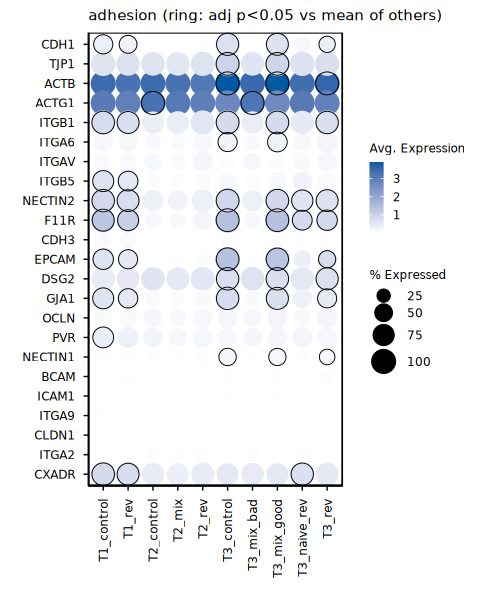

In [19]:
make_gene_dotplot(
  combined_df = combined_df,
  sample = "sample",
  target_genes = adhesion  ,
  w = 4, h = 5,
  title = "adhesion",
  endcolor = "#005AA3"
)

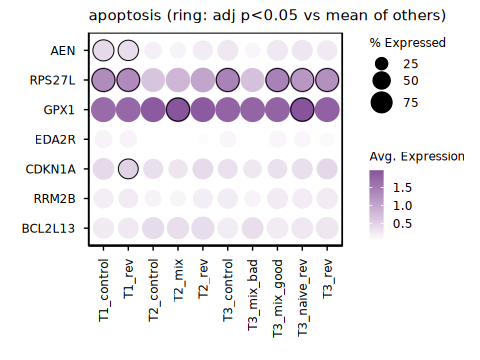

In [20]:
make_gene_dotplot(
  combined_df = combined_df,
  sample = "sample",
  target_genes =  apoptosis,
  w = 4, h = 3,
  title = "apoptosis", 
  endcolor = "#87549B"
)

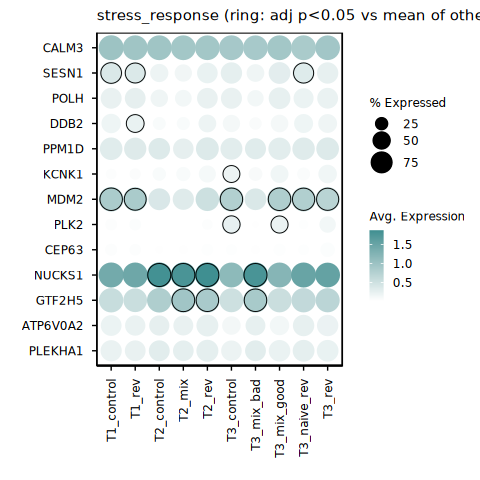

In [21]:
make_gene_dotplot(
  combined_df = combined_df,
  sample = "sample",
  target_genes =  stress_response,
  w = 4, h = 4,
  title = "stress_response",
  endcolor = "#3F8F91"
)

### plots - by celltype

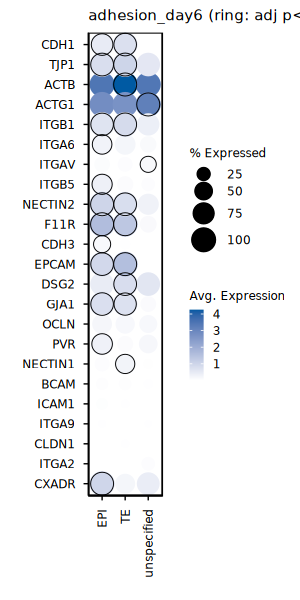

In [22]:
make_gene_dotplot(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "celltype_coarse",
  target_genes = adhesion  ,
  w = 2.5, h = 5,
  title = "adhesion_day6",
  endcolor = "#005AA3"
)

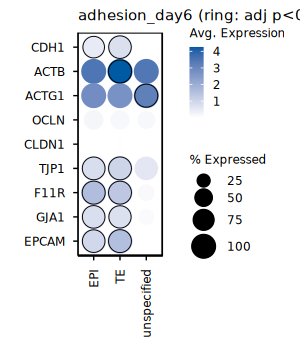

In [23]:
make_gene_dotplot(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "celltype_coarse",
  target_genes = adhesion_sub  ,
  w = 2.5, h = 3,
  title = "adhesion_day6",
  endcolor = "#005AA3"
)

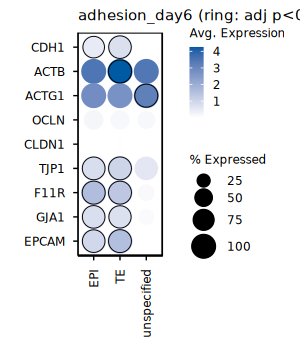

In [24]:
make_gene_dotplot(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "celltype_coarse",
  target_genes = adhesion_sub  ,
  w = 2.5, h = 3,
  title = "adhesion_day6",
  endcolor = "#005AA3"
)

In [25]:
head(combined_df)

barcode,dataset,cell.ID_,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,UMAP1,UMAP2,AEN,RPS27L,GPX1,EDA2R,CDKN1A,RRM2B,BCL2L13,CALM3,SESN1,POLH,DDB2,PPM1D,KCNK1,MDM2,PLK2,CEP63,NUCKS1,GTF2H5,ATP6V0A2,PLEKHA1,CDH1,TJP1,ACTB,ACTG1,ITGB1,ITGA6,ITGAV,ITGB5,NECTIN2,F11R,CDH3,EPCAM,DSG2,GJA1,OCLN,PVR,NECTIN1,BCAM,ICAM1,ITGA9,CLDN1,ITGA2,CXADR,GATA2,GATA3,CDX2,TFAP2C,KRT7,KRT18,OVOL1,POU5F1,GDF3,ARGFX,NANOG,SOX2,KLF17,TDGF1,CDH2,SNAI1,SNAI2,ZEB1,ZEB2,VIM,cell,...1,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,COMPLEMENT,DNA_REPAIR,E2F_TARGETS,EPITHELIAL_MESENCHYMAL_TRANSITION,ESTROGEN_RESPONSE_EARLY,ESTROGEN_RESPONSE_LATE,FATTY_ACID_METABOLISM,G2M_CHECKPOINT,GLYCOLYSIS,HEDGEHOG_SIGNALING,HEME_METABOLISM,HYPOXIA,IL2_STAT5_SIGNALING,IL6_JAK_STAT3_SIGNALING,INFLAMMATORY_RESPONSE,INTERFERON_ALPHA_RESPONSE,INTERFERON_GAMMA_RESPONSE,KRAS_SIGNALING_DN,KRAS_SIGNALING_UP,MITOTIC_SPINDLE,MTORC1_SIGNALING,MYC_TARGETS_V1,MYC_TARGETS_V2,MYOGENESIS,NOTCH_SIGNALING,OXIDATIVE_PHOSPHORYLATION,P53_PATHWAY,PANCREAS_BETA_CELLS,PEROXISOME,PI3K_AKT_MTOR_SIGNALING,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,Embryo-Imp15265938,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,0.07129456,FALSE,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.291071261,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified,6.524751,3.467301,0.0000000,1.734258,1.503753,0.0000000,1.0113358,0.0000000,0.0000000,1.5037534,0.7729656,0.7729656,1.0113358,0.4593789,0.0000000,0.0000000,0,0,1.921457,1.2036812,0.4593789,0.4593789,0.0000000,0.4593789,3.325833,3.090645,0.0000000,0.4593789,0,0.0000000,0.4593789,0.7729656,0.0000000,0.0000000,0.7729656,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0.0000000,0.0000000,0.0000000,0,0.4593789,0.0000000,0,0.0000000,0,0.000000,0.0000000,0.0000000,0.0000000,0.4593789,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.7729656,0.0000000,2.583612,0,14348,diploid,diploid,0,0,44,0,2.131029,-0.4075289,0.05464372,0.57211532,-1.1875900,1.252161,-1.95

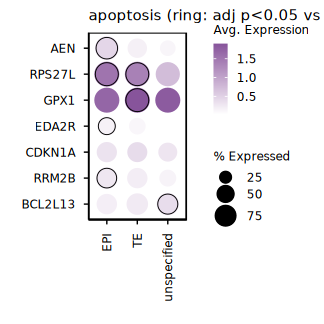

In [26]:
make_gene_dotplot(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "celltype_coarse",
  target_genes =  apoptosis,
  w = 2.7, h = 2.7,
  title = "apoptosis", 
  endcolor = "#87549B"
)

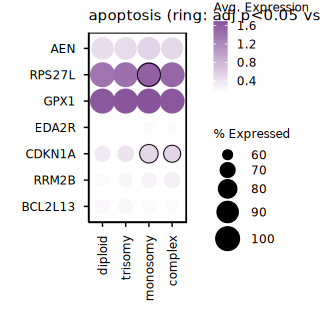

In [27]:
make_gene_dotplot(
  combined_df = combined_df %>% subset(timepoint == "day1")%>% subset(celltype_coarse == "EPI"),
  sample = "ploidy",
  target_genes =  apoptosis,
  w = 2.7, h = 2.7,
  title = "apoptosis", 
  endcolor = "#87549B",
  
)

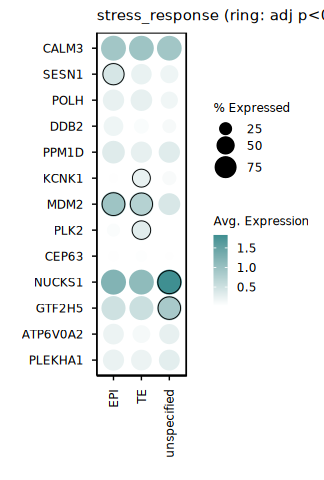

In [28]:
make_gene_dotplot(
  combined_df = combined_df,
  sample = "celltype_coarse",
  target_genes =  stress_response,
  w = 2.7, h = 4,
  title = "stress_response",
  endcolor = "#3F8F91"
)

### plots- by ploidy

In [29]:
unique(combined_df$ploidy)

[1] diploid  monosomy trisomy  complex 
Levels: diploid trisomy monosomy complex

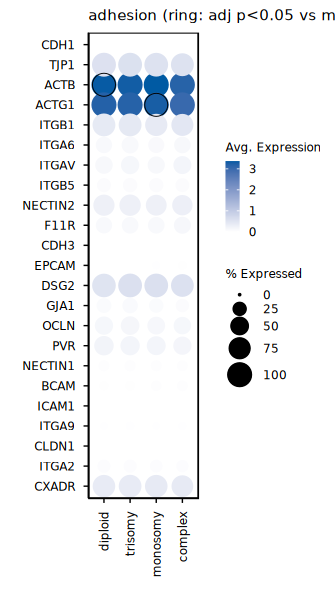

In [30]:
make_gene_dotplot(
  combined_df = combined_df%>% subset(timepoint == "day4")%>% subset(celltype_coarse == "unspecified"),
  sample = "ploidy",
  target_genes = adhesion  ,
  w = 2.8, h = 5,
  title = "adhesion",
  endcolor = "#005AA3"
)

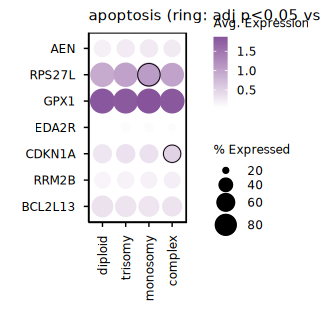

In [31]:
make_gene_dotplot(
  combined_df = combined_df,
  sample = "ploidy",
  target_genes =  apoptosis,
  w = 2.7, h = 2.7,
  title = "apoptosis", 
  endcolor = "#87549B"
)

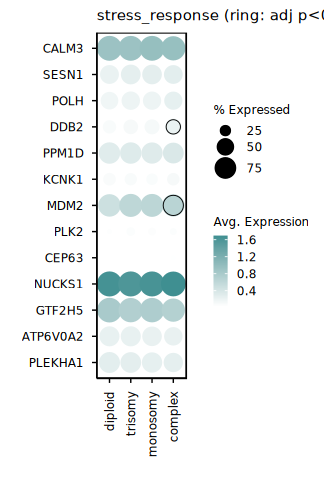

In [32]:
make_gene_dotplot(
  combined_df = combined_df,
  sample = "ploidy",
  target_genes =  stress_response,
  w = 2.7, h = 4,
  title = "stress_response",
  endcolor = "#3F8F91"
)

Dropping missing genes: TWIST



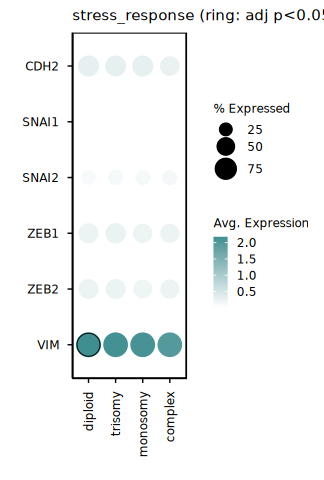

In [33]:
make_gene_dotplot(
  combined_df = combined_df%>% subset(timepoint == "day4"),
  sample = "ploidy",
  target_genes =  EMT_genes,
  w = 2.7, h = 4,
  title = "stress_response",
  endcolor = "#3F8F91"
)

## B_Dotplot (zscored)

### function

In [34]:
make_gene_dotplot_zscored <- function(combined_df,
                              sample = "sample",
                              target_genes,
                              w = 4, h = 3,
                              title = "Gene Expression across Ploidy",
                              expr_thresh = 0, endcolor = "#3F8F91") {
    
  # Keep only columns we need 
  df_sub <- combined_df %>%
    select(all_of(sample), any_of(target_genes))

  # Check genes present
  present_genes <- intersect(target_genes, colnames(df_sub))
  missing_genes <- setdiff(target_genes, present_genes)
    
  if (length(missing_genes) > 0) {
    message("Dropping missing genes: ", paste(missing_genes, collapse = ", "))
  }

  # Summarise for dotplot
  dot_data <- df_sub %>%
    pivot_longer(
      cols = any_of(present_genes),
      names_to = "gene",
      values_to = "expression"
    ) %>%
    group_by(gene, .data[[sample]]) %>%
    summarise(
      avg_exp = mean(expression, na.rm = TRUE),
      pct_exp = sum(expression > expr_thresh, na.rm = TRUE) / n() * 100,
      .groups = "drop"
    )%>%
      group_by(gene) %>%
      mutate(
        avg_exp_z = as.numeric(scale(avg_exp))   # (x - mean)/sd within gene
      ) %>%
      ungroup()

  # Gene order (top-to-bottom = target_genes order reversed)
  dot_data$gene <- factor(dot_data$gene, levels = rev(target_genes))

  # Plot size 
  options(repr.plot.width = w, repr.plot.height = h)

  p_dot <- ggplot(dot_data, aes(x = .data[[sample]], y = gene)) +
    geom_point(aes(size = pct_exp, color = avg_exp_z)) +
    scale_color_gradientn(colors = c("white", endcolor)) +
    scale_size_continuous(range = c(0, 6), name = "% Expressed") +
    labs(
      x = "",
      y = "",
      color = "z-score",
      title = sprintf("%s_z-scored", title)
    ) +
    settheme +
    theme(
      axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
      panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.5),
      legend.position = "right"
    )


    ggsave( filename = sprintf("%s/B_%s_%s_dotplot_zscored.pdf", outdir, title, sample), plot =  p_dot, width = w, height = h)
    options(repr.plot.width=w, repr.plot.height=h)
    p_dot
}


### plots - by sample

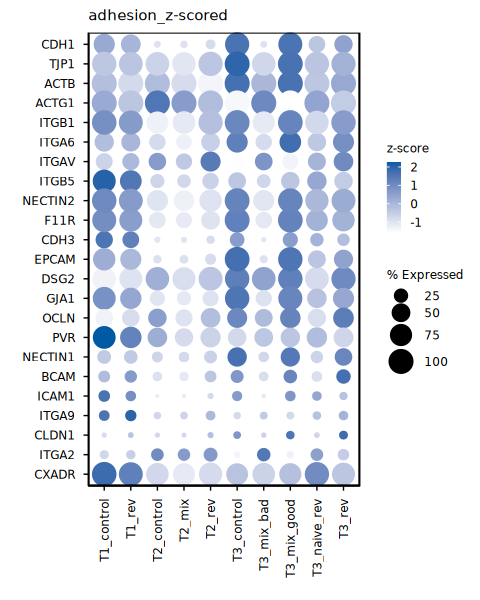

In [35]:
make_gene_dotplot_zscored(
  combined_df = combined_df,
  sample = "sample",
  target_genes = adhesion  ,
  w = 4, h = 5,
  title = "adhesion",
  endcolor = "#005AA3"
)

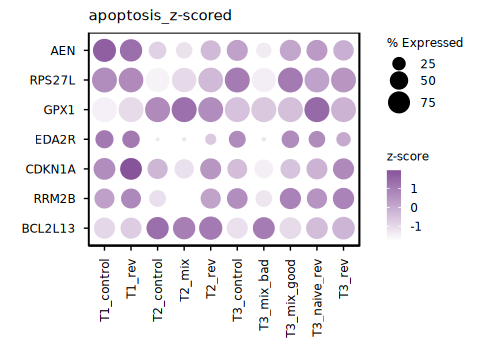

In [36]:
make_gene_dotplot_zscored(
  combined_df = combined_df,
  sample = "sample",
  target_genes =  apoptosis,
  w = 4, h = 3,
  title = "apoptosis", 
  endcolor = "#87549B"
)

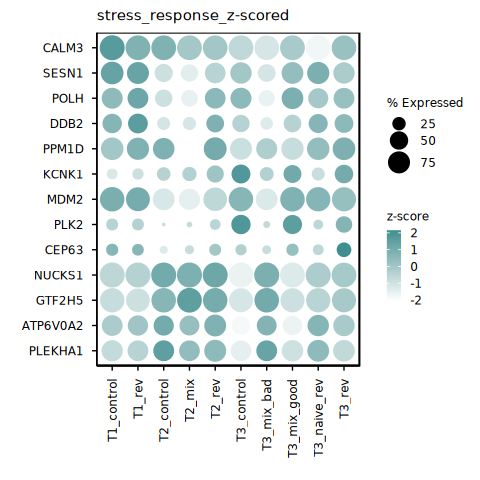

In [37]:
make_gene_dotplot_zscored(
  combined_df = combined_df,
  sample = "sample",
  target_genes =  stress_response,
  w = 4, h = 4,
  title = "stress_response",
  endcolor = "#3F8F91"
)

### plots- by celltype

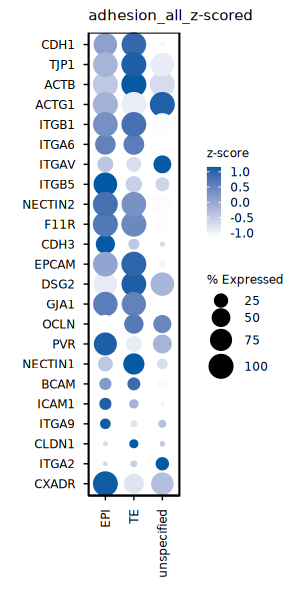

In [38]:
make_gene_dotplot_zscored(
  combined_df = combined_df,
  sample = "celltype_coarse",
  target_genes = adhesion  ,
  w = 2.5, h = 5,
  title = "adhesion_all",
  endcolor = "#005AA3"
)

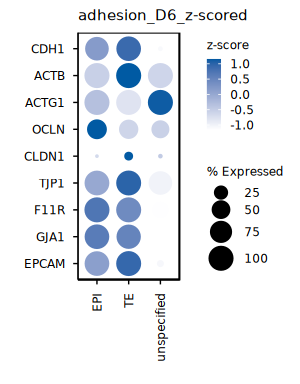

In [39]:
make_gene_dotplot_zscored(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "celltype_coarse",
  target_genes = adhesion_sub,
  w = 2.5, h = 3.2,
  title = "adhesion_D6",
  endcolor = "#005AA3"
)

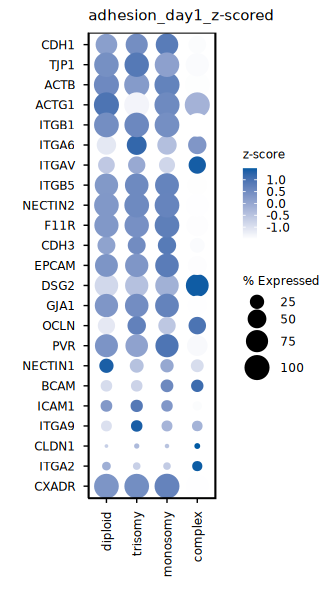

In [40]:
make_gene_dotplot_zscored(
  combined_df = combined_df%>%subset(timepoint == "day1"),
  sample = "ploidy",
  target_genes = adhesion  ,
  w = 2.8, h = 5,
  title = "adhesion_day1",
  endcolor = "#005AA3"
)

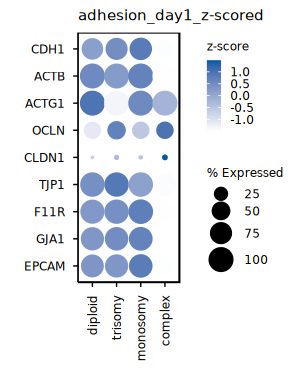

In [41]:
make_gene_dotplot_zscored(
  combined_df = combined_df%>%subset(timepoint == "day1"),
  sample = "ploidy",
  target_genes = adhesion_sub  ,
  w = 2.5, h = 3.2,
  title = "adhesion_day1",
  endcolor = "#005AA3"
)

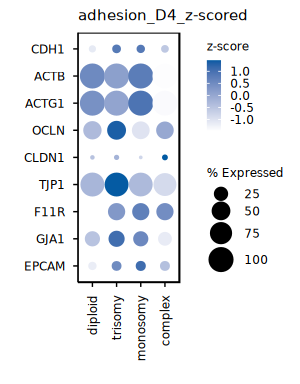

In [42]:
make_gene_dotplot_zscored(
  combined_df = combined_df %>% subset(timepoint == "day4"),
  sample = "ploidy",
  target_genes = adhesion_sub ,
  w = 2.5, h = 3.2,
  title = "adhesion_D4",
  endcolor = "#005AA3"
)

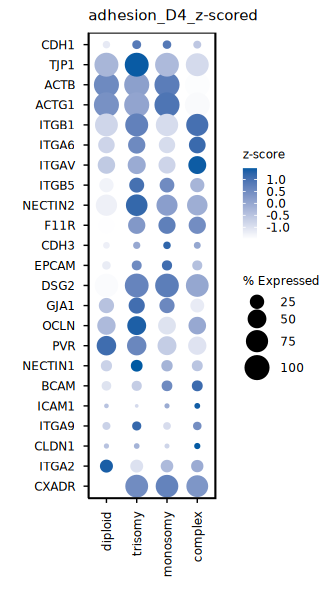

In [43]:
make_gene_dotplot_zscored(
  combined_df = combined_df %>% subset(timepoint == "day4"),
  sample = "ploidy",
  target_genes = adhesion ,
  w = 2.8, h = 5,
  title = "adhesion_D4",
  endcolor = "#005AA3"
)

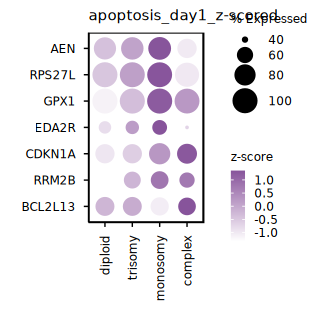

In [44]:
make_gene_dotplot_zscored(
  combined_df = combined_df %>% subset(timepoint == "day1"),
  sample = "ploidy",
  target_genes =  apoptosis,
  w = 2.7, h = 2.7,
  title = "apoptosis_day1", 
  endcolor = "#87549B"
)

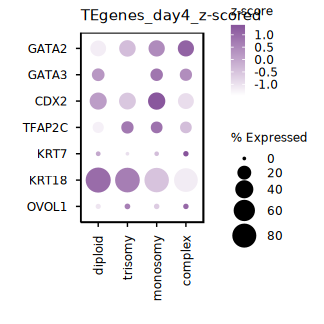

In [45]:
make_gene_dotplot_zscored(
  combined_df = combined_df %>% subset(timepoint == "day4"),
  sample = "ploidy",
  target_genes =  TE_genes,
  w = 2.7, h = 2.7,
  title = "TEgenes_day4", 
  endcolor = "#87549B"
)

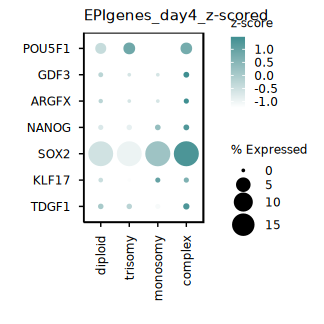

In [46]:
make_gene_dotplot_zscored(
  combined_df = combined_df%>% subset(timepoint == "day4")%>% subset(celltype_coarse == "unspecified"),
  sample = "ploidy",
  target_genes =  EPI_genes,
  w = 2.7, h = 2.7,
  title = "EPIgenes_day4",
  endcolor = "#3F8F91"
)

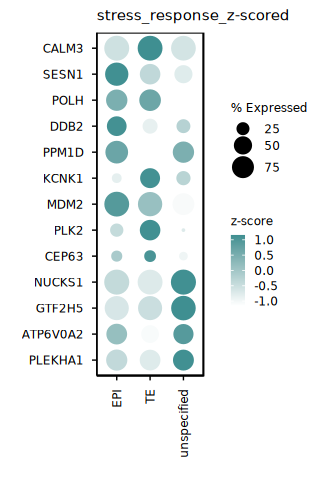

In [47]:
make_gene_dotplot_zscored(
  combined_df = combined_df,
  sample = "celltype_coarse",
  target_genes =  stress_response,
  w = 2.7, h = 4,
  title = "stress_response",
  endcolor = "#3F8F91"
)

Dropping missing genes: TWIST



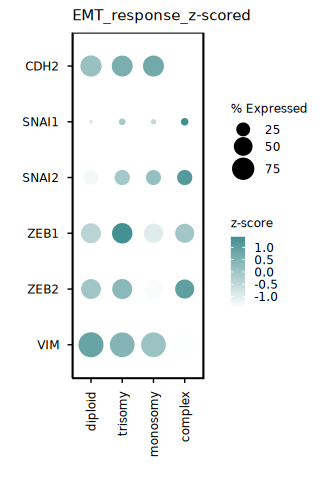

In [48]:
make_gene_dotplot_zscored(
  combined_df = combined_df%>% subset(timepoint == "day4"),
  sample = "ploidy",
  target_genes =  EMT_genes,
  w = 2.7, h = 4,
  title = "EMT_response",
  endcolor = "#3F8F91"
)

### per chr

In [49]:
library(dplyr)
library(stringr)

# 1. Define the specific chromosomes you want to detect
# We wrap them in word boundaries (\\b) so '4+' doesn't match inside '14+'
target_pattern <- "\\b(7|13|4|11|21|9)\\+"

combined_df <- combined_df %>%
  mutate(developed_karyo = case_when(
    # 1. Exact match for diploid
    karyotype == "diploid" ~ "diploid",
    
    # 2. Check for specific developed chromosomes
    # This regex looks for 7, 13, 4, etc. followed immediately by a +
    str_detect(karyotype, target_pattern) & ploidy == "trisomy" ~ "aneu_developed",
    
    # 3. Everything else (including 14+, 17+, etc.)
    TRUE ~ "aneu_failed"
  ))


In [50]:
# --- Verification Step (Optional) ---
# Check specific examples to make sure logic holds
test_cases <- combined_df %>%
  filter(karyotype %in% c("4+, 17+") )%>%
  select(karyotype, developed_karyo)

print(test_cases)

# A tibble: 0 × 2
# ℹ 2 variables: karyotype <chr>, developed_karyo <chr>


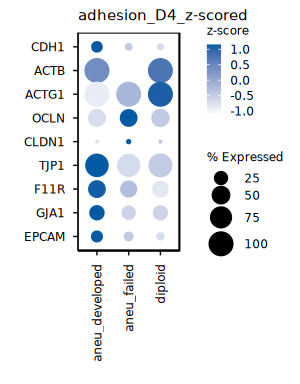

In [51]:
make_gene_dotplot_zscored(
  combined_df = combined_df %>% subset(timepoint == "day4"),
  sample = "developed_karyo",
  target_genes = adhesion_sub ,
  w = 2.5, h = 3.2,
  title = "adhesion_D4",
  endcolor = "#005AA3"
)

## C_Heatmap

### function

In [52]:
make_gene_heatmap <- function(combined_df,
                              sample = "sample",
                              facet_col = NULL,                 # optional facet column
                              target_genes,
                              w = 4, h = 3,
                              title = "Gene Expression across Ploidy",
                              endcolor = "#3F8F91",
                              zscore_within_celltype = FALSE,   # used only if faceting
                              zscore = FALSE,
                              facet_scales = "fixed",
                             col_palette= "RdPu") {         # expose scales option

  # decide if we can facet
  use_facet <- !is.null(facet_col) && facet_col %in% names(combined_df)

  # columns to keep
  keep_cols <- c(sample, target_genes)
  if (use_facet) keep_cols <- c(facet_col, keep_cols)

  df_sub <- combined_df %>% select(all_of(keep_cols))

  # gene presence check
  present_genes <- intersect(target_genes, colnames(df_sub))
  missing_genes <- setdiff(target_genes, present_genes)
  if (length(missing_genes) > 0) {
    message("Dropping missing genes: ", paste(missing_genes, collapse = ", "))
  }

  # summarise per gene × sample [× facet]
  group_vars <- c("gene", sample)
  if (use_facet) group_vars <- c(group_vars, facet_col)

  dot_data <- df_sub %>%
    pivot_longer(cols = any_of(present_genes),
                 names_to = "gene", values_to = "expression") %>%
    group_by(across(all_of(group_vars))) %>%
    summarise(
      avg_exp = mean(expression, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    {
      if (zscore) {
        if (use_facet && zscore_within_celltype) {
          group_by(., gene, .data[[facet_col]])
        } else {
          group_by(., gene)
        }
      } else .
    } %>%
    { if (zscore) mutate(., avg_exp_z = as.numeric(scale(avg_exp))) else . } %>%
    ungroup()

  # order genes as given (top-to-bottom)
  dot_data$gene <- factor(dot_data$gene, levels = rev(target_genes))

  # plot
  options(repr.plot.width = w, repr.plot.height = h)
  fill_var <- if (isTRUE(zscore)) "avg_exp_z" else "avg_exp"
  zstring  <- if (isTRUE(zscore)) "_zscored" else ""

  p <- ggplot(dot_data, aes(x = .data[[sample]], y = gene)) +
    geom_tile(aes(fill = .data[[fill_var]]), color = "black") +
     scale_fill_distiller(
  palette = col_palette , type = "seq", direction = 1,
  na.value = "grey90",
  oob = scales::squish
)+
    labs(x = "", y = "", title = sprintf("%s%s", title, zstring)) +
    settheme +
    theme(
      axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
      axis.ticks.x = element_line(),
      strip.background = element_blank(),
      panel.background = element_rect(fill = "#E0E0E0"),
      panel.grid = element_blank(),
      legend.position = "right",
      axis.line = element_blank(),
      panel.border = element_blank()
    )

  # add facet only if requested and valid
  if (use_facet) {
    p <- p + facet_wrap(vars(!!sym(facet_col)), scales = facet_scales)
  } else if (!is.null(facet_col) && !facet_col %in% names(combined_df)) {
    warning(sprintf("facet_col='%s' not found; skipping faceting.", facet_col))
  }

  ggsave(filename = sprintf("%s/C_%s%s_%s_heatmap.pdf", outdir, title, zstring, sample),
         plot = p, width = w, height = h)
  p
}

### plots

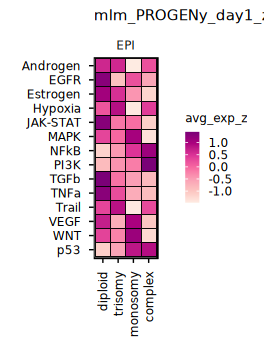

In [53]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day1")%>% subset(celltype_coarse == "EPI"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = mlm_PROGENy_var  ,
  w = 2.2, h = 3,
  title = "mlm_PROGENy_day1",
  endcolor = "#D24D63",
  zscore = TRUE,
  zscore_within_celltype = TRUE
)

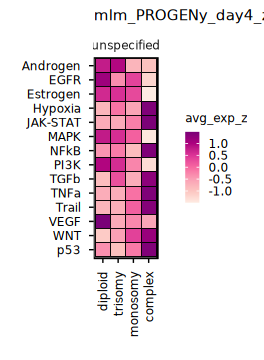

In [54]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day4")%>% subset(celltype_coarse == "unspecified"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = mlm_PROGENy_var  ,
  w = 2.2, h = 3,
  title = "mlm_PROGENy_day4",
  endcolor = "#D24D63",
  zscore = TRUE,
  zscore_within_celltype = TRUE
)

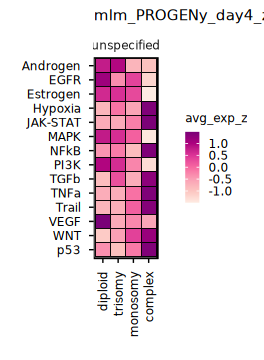

In [55]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day4")%>% subset(celltype_coarse == "unspecified"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = mlm_PROGENy_var  ,
  w = 2.2, h = 3,
  title = "mlm_PROGENy_day4",
  endcolor = "#D24D63",
  zscore = TRUE,
  zscore_within_celltype = TRUE
)

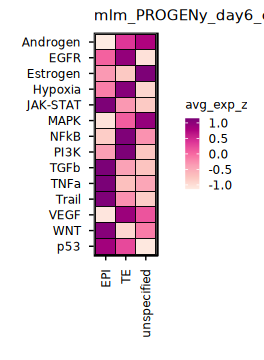

In [56]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "celltype_coarse",
  #facet_col = "celltype_coarse", 
  target_genes = mlm_PROGENy_var  ,
  w = 2.2, h = 3,
  title = "mlm_PROGENy_day6_celltype",
  endcolor = "#D24D63",
  zscore = TRUE,
  zscore_within_celltype = TRUE
)

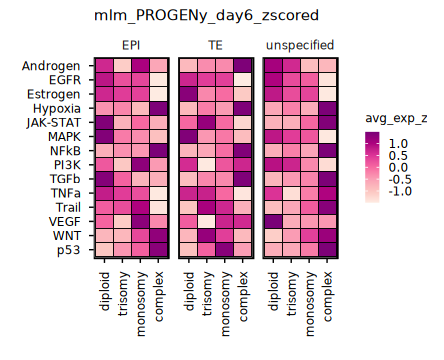

In [57]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = mlm_PROGENy_var  ,
  w = 3.7, h = 3,
  title = "mlm_PROGENy_day6",
  endcolor = "#D24D63",
  zscore = TRUE,
  zscore_within_celltype = TRUE
)

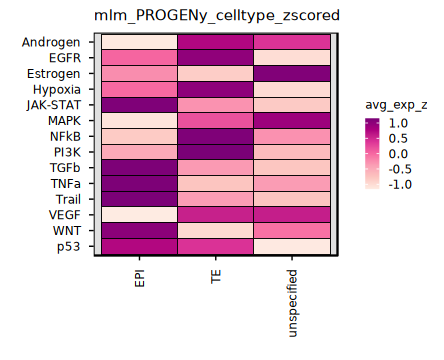

In [58]:
make_gene_heatmap(
  combined_df = combined_df,
  sample = "celltype_coarse",
  facet_col = NULL, 
  target_genes = mlm_PROGENy_var  ,
  w = 3.7, h = 3,
  title = "mlm_PROGENy_celltype",
  endcolor = "#D24D63",
  zscore = TRUE,
  zscore_within_celltype = FALSE
)

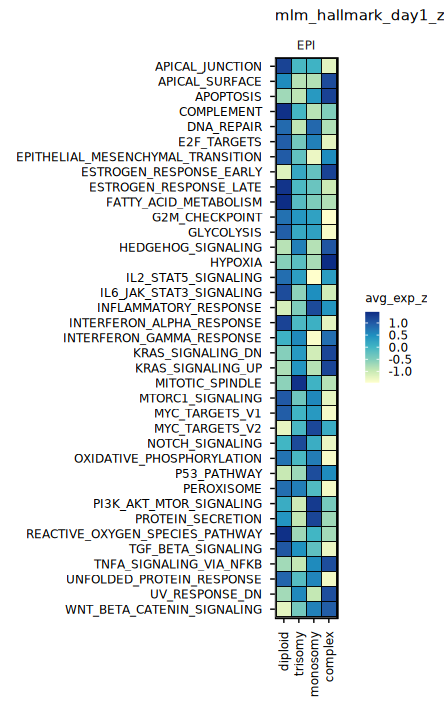

In [59]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day1") %>% subset(celltype_coarse == "EPI"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = mlm_hallmark_var  ,
  w = 3.7, h = 6,
  title = "mlm_hallmark_day1",
  endcolor = "#66437F",
  zscore = TRUE,
  zscore_within_celltype = TRUE,
 col_palette= "YlGnBu"
)

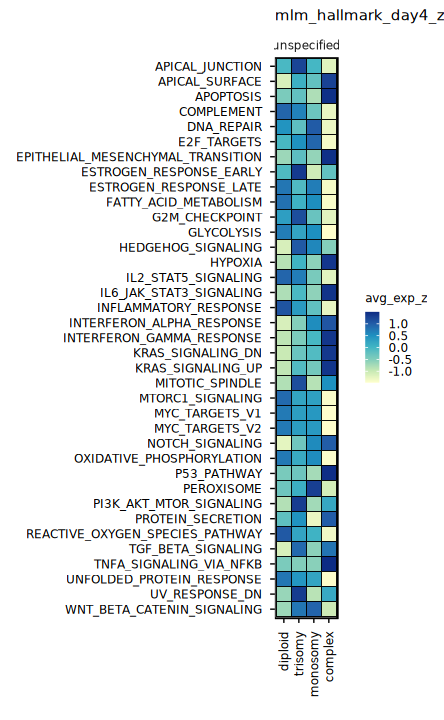

In [60]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day4") %>% subset(celltype_coarse == "unspecified"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = mlm_hallmark_var  ,
  w = 3.7, h = 6,
  title = "mlm_hallmark_day4",
  endcolor = "#66437F",
  zscore = TRUE,
  zscore_within_celltype = TRUE,
 col_palette= "YlGnBu"
)

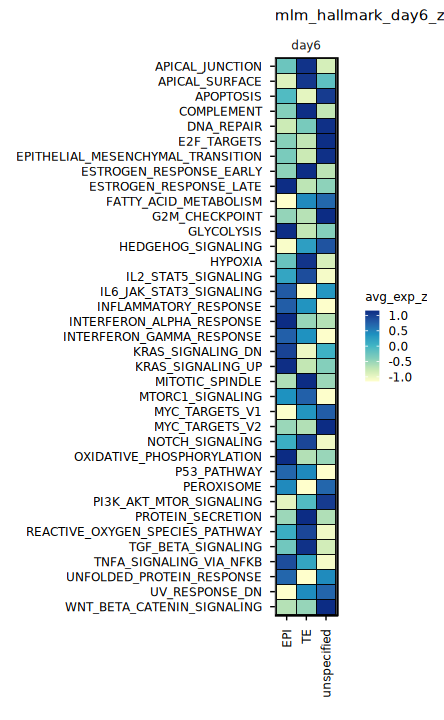

In [61]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "celltype_coarse",
  facet_col = "timepoint", 
  target_genes = mlm_hallmark_var  ,
  w = 3.7, h = 6,
  title = "mlm_hallmark_day6",
  endcolor = "#66437F",
  zscore = TRUE,
  zscore_within_celltype = TRUE,
 col_palette= "YlGnBu"
)

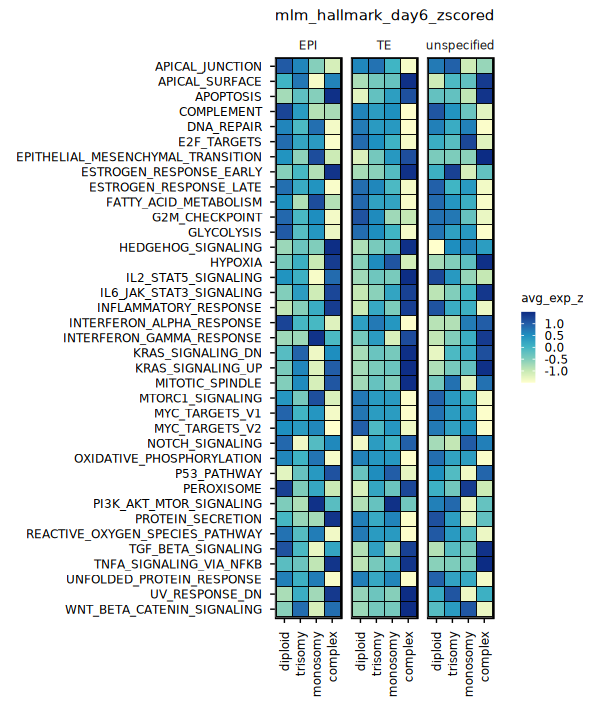

In [62]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = mlm_hallmark_var  ,
  w = 5, h = 6,
  title = "mlm_hallmark_day6",
  endcolor = "#66437F",
  zscore = TRUE,
  zscore_within_celltype = TRUE,
 col_palette= "YlGnBu"
)

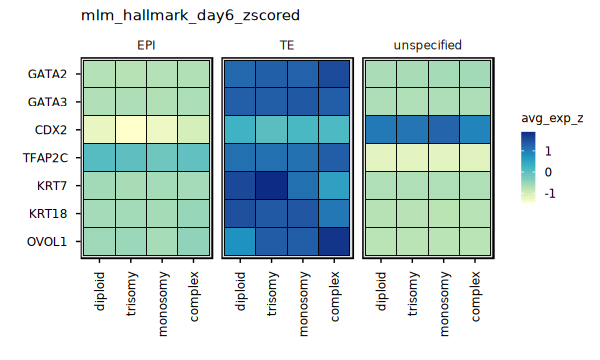

In [63]:
make_gene_heatmap(
  combined_df = combined_df %>% subset(timepoint == "day6"),
  sample = "ploidy",
  facet_col = "celltype_coarse", 
  target_genes = TE_genes  ,
  w = 5, h = 3,
  title = "mlm_hallmark_day6",
  endcolor = "#66437F",
  zscore = TRUE,
  zscore_within_celltype = FALSE,
 col_palette= "YlGnBu"
)

## Boxplot

In [64]:
plot_genes = stress_response

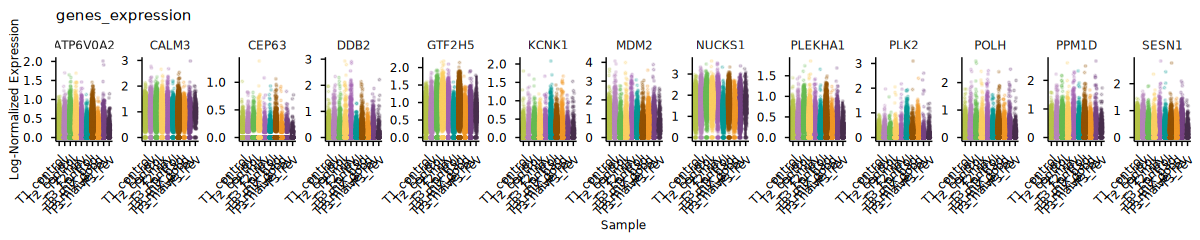

In [65]:

#reformat
plot_data_long <- combined_df %>%
  pivot_longer(
    cols = any_of(plot_genes), # Select the gene columns
    names_to = "gene", 
    values_to = "expression"
  )

#plot
title = "genes_expression"

w <- 10
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# 2. Create the Plot
p <- ggplot(plot_data_long, aes(x = sample, y = expression, fill = sample, color = sample )) +
  # Add the boxplot layer (hiding outliers because we add them with jitter)
  geom_boxplot(outlier.shape = NA, alpha = 0.5, width = 0.6) +
  
  # Add the jittered dots
  geom_jitter(width = 0.2, size = 0.1, alpha = 0.2) +
  
  # Facet by gene
  facet_wrap(~gene, scales = "free_y", nrow = 1) +
  
  # Labels and Theme
  labs(
    title = title,
    x = "Sample",
    y = "Log-Normalized Expression"
  ) +
  settheme + # Your custom lab theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )+scale_fill_manual(values=color_sample)+
  scale_color_manual(values=color_sample)

# Save and Display
#ggsave(file.path(out_dir, "gene_boxplot_per_sample.pdf"), plot = p, width = 6, height = 4)
p

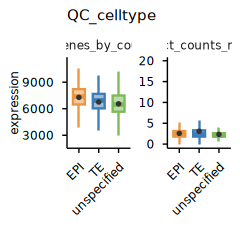

In [66]:
plot_genes =  c("n_genes_by_counts","pct_counts_mt")

#reformat
plot_data_long <- combined_df %>%
  pivot_longer(
    cols = any_of(plot_genes), # Select the gene columns
    names_to = "gene", 
    values_to = "expression"
  )

#plot
title = "QC_celltype"

w <- 2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# 2. Create the Plot
p <- ggplot(plot_data_long, aes(x = celltype_coarse, y = expression, fill = celltype_coarse, color = celltype_coarse))+
   geom_boxplot(outlier.shape = NA, alpha = 0.5, width = 0.6) +
  
  # Add the jittered dots
 # geom_jitter(width = 0.2, size = 0.1, alpha = 0.1) +
  
  # Facet by gene
  facet_wrap(~gene, scales = "free_y", nrow = 1) +
  
  # Labels and Theme
  labs(
    title = title,
    x = "",
   # y = "Log-Normalized Expression"
  ) +
  # mean ± SE
  stat_summary(fun = mean, geom = "point", size = 0.5, colour = "grey20") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.15, colour = "grey20") +
  labs(
    #x = "Sample",
    #y = "% aneuploid cells/embryo"
  ) +
  settheme + # Your custom lab theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )+scale_fill_manual(values=color_celltype)+
  scale_color_manual(values=color_celltype)
# Save and Display
  ggsave(filename = sprintf("%s/D_%s_boxplot.pdf", outdir, title),
         plot = p, width = w, height = h)
p

## D_Violin

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


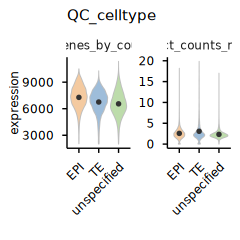

In [67]:
plot_genes =  c("n_genes_by_counts","pct_counts_mt")

#reformat
plot_data_long <- combined_df %>%
  pivot_longer(
    cols = any_of(plot_genes), # Select the gene columns
    names_to = "gene", 
    values_to = "expression"
  )



#plot
title = "QC_celltype"

w <- 2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# 2. Create the Plot
p <- ggplot(plot_data_long, aes(x = celltype_coarse, y = expression, fill = celltype_coarse, color = celltype_coarse))+
  # violin per sample within each ploidy facet
  geom_violin(
    alpha = 0.5,
    linewidth = 0.2,
    trim = TRUE,
      color = "grey"
  )+
  
  # Add the jittered dots
 # geom_jitter(width = 0.2, size = 0.1, alpha = 0.1) +
  
  # Facet by gene
  facet_wrap(~gene, scales = "free_y", nrow = 1) +
  
  # Labels and Theme
  labs(
    title = title,
    x = "",
   # y = "Log-Normalized Expression"
  ) +
  # mean ± SE
  stat_summary(fun = mean, geom = "point", size = 0.5, colour = "grey20") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.15, colour = "grey20") +
  labs(
    #x = "Sample",
    #y = "% aneuploid cells/embryo"
  ) +
  settheme + # Your custom lab theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )+scale_fill_manual(values=color_celltype)+
  scale_color_manual(values=color_celltype)
# Save and Display
  ggsave(filename = sprintf("%s/D_%s_violin.pdf", outdir, title),
         plot = p, width = w, height = h)
p

Warning message in geom_violin(outlier.shape = NA, alpha = 0.5, width = 0.6):
“Ignoring unknown parameters: `outlier.shape`”


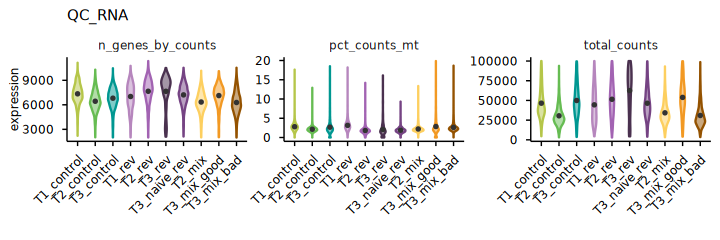

In [77]:
plot_genes =  c('total_counts', "n_genes_by_counts","pct_counts_mt")
order = c(
    "T1_control", "T2_control", "T3_control",
    "T1_rev", "T2_rev", "T3_rev", "T3_naive_rev",
    "T2_mix", "T3_mix_good", "T3_mix_bad")

#reformat
plot_data_long <- combined_df %>%
  pivot_longer(
    cols = any_of(plot_genes), # Select the gene columns
    names_to = "gene", 
    values_to = "expression"
  )

 # order genes as given (top-to-bottom)
plot_data_long$sample <- factor(plot_data_long$sample, levels = order)

#plot
title = "QC_RNA"

w <- 6
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# 2. Create the Plot
p <- ggplot(plot_data_long, aes(x = sample, y = expression, fill = sample, color = sample))+
   geom_violin(outlier.shape = NA, alpha = 0.5, width = 0.6) +
  
  # Add the jittered dots
 # geom_jitter(width = 0.2, size = 0.1, alpha = 0.1) +
  
  # Facet by gene
  facet_wrap(~gene, scales = "free_y", nrow = 1) +
  
  # Labels and Theme
  labs(
    title = title,
    x = "",
   # y = "Log-Normalized Expression"
  ) +
  # mean ± SE
  stat_summary(fun = mean, geom = "point", size = 0.5, colour = "grey20") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.15, colour = "grey20") +
  labs(
    #x = "Sample",
    #y = "% aneuploid cells/embryo"
  ) +
  settheme + # Your custom lab theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )+scale_fill_manual(values=color_sample)+
  scale_color_manual(values=color_sample)
# Save and Display
  ggsave(filename = sprintf("%s/D_%s_violin.pdf", outdir, title),
         plot = p, width = w, height = h)
p

In [78]:
sprintf("%s/D_%s_violin.pdf", outdir, title)

[1] "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/11_geneexpression/D_QC_RNA_violin.pdf"